# K-Means Clustering, From Scratch\n\nK-means alternates between two steps until nothing moves:\n\n1. **Assign** every point to its nearest centroid.\n2. **Update** each centroid to the mean of the points now assigned to it.\n\nRepeat until convergence. It always converges (the objective can only go down or stay the same at each step) — but it's a local optimizer, so *where it converges to* depends heavily on where the centroids started.\n\nThis notebook implements Lloyd's algorithm from scratch in numpy — no `sklearn.cluster.KMeans` — and compares two initialization strategies across many random seeds: naive random init vs. **k-means++**, which spreads the initial centroids out on purpose.\n\nThe companion interactive version — same math, both strategies converging live side by side — lives at `web/`.

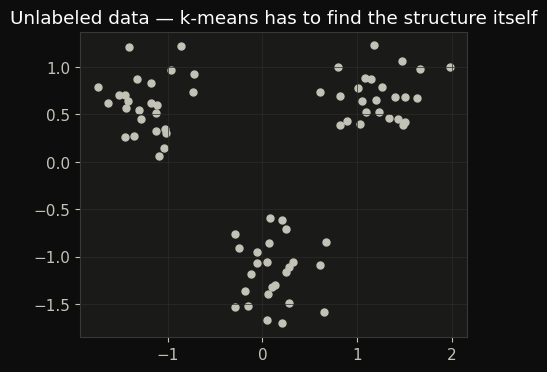

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.facecolor": "#0d0d0d",
    "axes.facecolor": "#1a1a19",
    "axes.edgecolor": "#383835",
    "axes.labelcolor": "#ffffff",
    "text.color": "#ffffff",
    "xtick.color": "#c3c2b7",
    "ytick.color": "#c3c2b7",
    "grid.color": "#2c2c2a",
    "axes.grid": True,
    "grid.linewidth": 0.5,
    "font.size": 11,
})

CLUSTER_COLORS = ["#3987e5", "#d95926", "#199e70"]


def make_blobs(per_cluster=25, seed=5):
    rng = np.random.default_rng(seed)
    centers = np.array([[-1.1, 0.7], [1.2, 0.8], [0.05, -1.2]])
    points = np.vstack([
        c + rng.normal(0, 0.32, size=(per_cluster, 2)) for c in centers
    ])
    return points


X = make_blobs()

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(*X.T, color="#c3c2b7", s=25)
ax.set_aspect("equal")
ax.set_title("Unlabeled data — k-means has to find the structure itself")
plt.show()

## Lloyd's algorithm

In [2]:
def assign_clusters(X, centroids):
    dists = np.linalg.norm(X[:, None, :] - centroids[None, :, :], axis=2)  # (n, k)
    return np.argmin(dists, axis=1)


def update_centroids(X, assignments, k, previous):
    centroids = previous.copy()
    for j in range(k):
        members = X[assignments == j]
        if len(members) > 0:
            centroids[j] = members.mean(axis=0)
        # empty cluster: leave the centroid where it was rather than producing NaN
    return centroids


def inertia(X, assignments, centroids):
    return float(np.sum((X - centroids[assignments]) ** 2))


def run_kmeans(X, init_centroids, max_iter=10):
    centroids = init_centroids.copy()
    assignments = assign_clusters(X, centroids)
    history = [(centroids.copy(), assignments.copy(), inertia(X, assignments, centroids))]

    for _ in range(max_iter):
        new_centroids = update_centroids(X, assignments, len(centroids), centroids)
        new_assignments = assign_clusters(X, new_centroids)
        moved = not np.allclose(new_centroids, centroids)
        centroids, assignments = new_centroids, new_assignments
        history.append((centroids.copy(), assignments.copy(), inertia(X, assignments, centroids)))
        if not moved:
            break
    return history

## Two ways to pick the starting centroids

**Random init** just samples $k$ data points uniformly. Nothing stops two of them from landing close together — which strands a centroid where it can't recover, since a cluster it never "owns" any points in just sits still forever.

**k-means++** picks the first centroid uniformly, then picks each subsequent one with probability proportional to its squared distance from the nearest centroid already chosen. Points far from existing centroids are far more likely to get picked next — which is exactly what spreads the initial centroids across the data instead of letting them cluster together by chance.

In [3]:
def random_init(X, k, seed):
    rng = np.random.default_rng(seed)
    idx = rng.choice(len(X), size=k, replace=False)
    return X[idx].copy()


def kmeans_plusplus_init(X, k, seed):
    rng = np.random.default_rng(seed)
    centroids = [X[rng.integers(len(X))]]
    while len(centroids) < k:
        dists = np.min([np.sum((X - c) ** 2, axis=1) for c in centroids], axis=0)
        probs = dists / dists.sum()
        next_idx = rng.choice(len(X), p=probs)
        centroids.append(X[next_idx])
    return np.array(centroids)

## One run, side by side

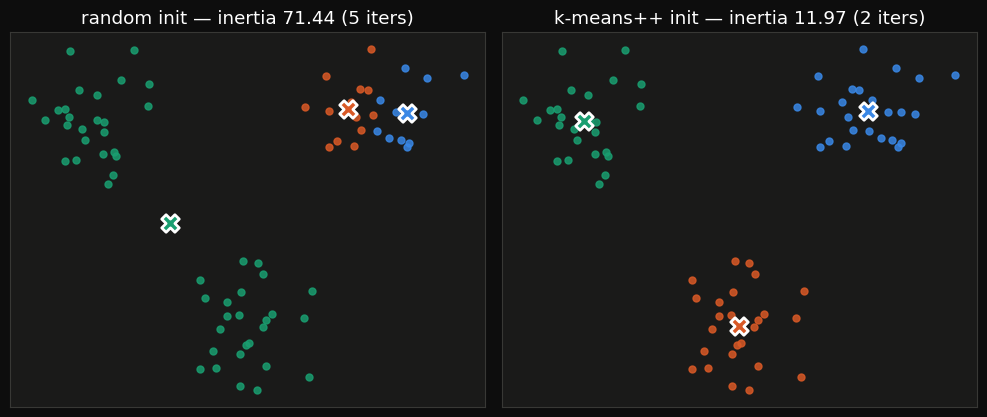

In [4]:
SEED = 1  # picked to visibly show a bad random-init outcome

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
for ax, init_fn, title in [
    (axes[0], random_init, "random init"),
    (axes[1], kmeans_plusplus_init, "k-means++ init"),
]:
    history = run_kmeans(X, init_fn(X, 3, SEED))
    centroids, assignments, final_inertia = history[-1]

    for j in range(3):
        members = X[assignments == j]
        ax.scatter(*members.T, color=CLUSTER_COLORS[j], s=25, alpha=0.85)
        ax.scatter(*centroids[j], color=CLUSTER_COLORS[j], s=160, edgecolor="#ffffff", linewidth=2, marker="X", zorder=3)

    ax.set_title(f"{title} — inertia {final_inertia:.2f} ({len(history)-1} iters)")
    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

## How reliable is each strategy?

One run isn't a fair comparison — random init is *random*, so let's run both strategies across 20 different seeds and look at the distribution of outcomes.

random init   — mean 27.25, min 11.97, max 84.85
k-means++     — mean 14.82, min 11.97, max 68.96


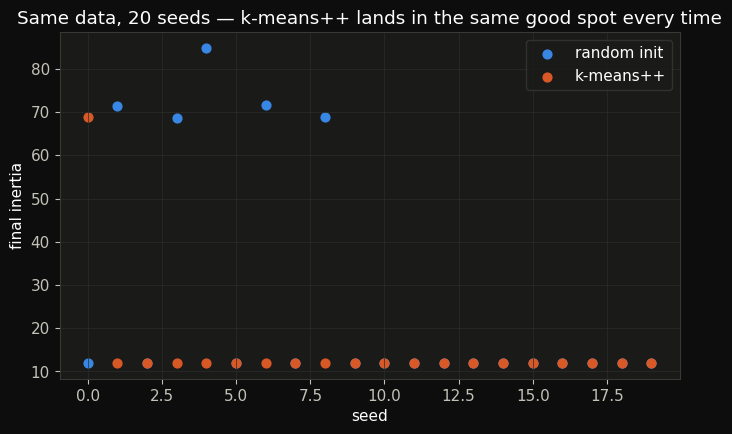

In [5]:
n_seeds = 20
random_inertias = []
kpp_inertias = []
for seed in range(n_seeds):
    random_inertias.append(run_kmeans(X, random_init(X, 3, seed))[-1][2])
    kpp_inertias.append(run_kmeans(X, kmeans_plusplus_init(X, 3, seed))[-1][2])

print(f"random init   — mean {np.mean(random_inertias):.2f}, min {np.min(random_inertias):.2f}, max {np.max(random_inertias):.2f}")
print(f"k-means++     — mean {np.mean(kpp_inertias):.2f}, min {np.min(kpp_inertias):.2f}, max {np.max(kpp_inertias):.2f}")

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.scatter(range(n_seeds), random_inertias, color="#3987e5", label="random init", s=40)
ax.scatter(range(n_seeds), kpp_inertias, color="#d95926", label="k-means++", s=40)
ax.set_xlabel("seed")
ax.set_ylabel("final inertia")
ax.set_title("Same data, 20 seeds — k-means++ lands in the same good spot every time")
ax.legend(facecolor="#1a1a19", edgecolor="#383835", labelcolor="#ffffff")
plt.show()

## Takeaways

- K-means is guaranteed to converge, but only to a *local* optimum — the update rule can only ever decrease inertia, never escape a bad basin it's already fallen into.
- Random init occasionally places two centroids close together, effectively wasting one — the third cluster it "should" own gets split off from a neighbor instead.
- k-means++ fixes this at initialization time, before a single assignment step runs, by biasing centroid selection toward points far from the ones already chosen.
- It isn't a silver bullet — across the 20 seeds above, k-means++ still lands in the bad basin once. But it does so far less often than random init (1 of 20 vs. 5 of 20 here), because it actively works against the failure mode rather than leaving it to chance. Initialization isn't a minor implementation detail — for k-means, it measurably changes how often you get the wrong answer.